# CellTypist - Bacteria dataset 
This CellTypist tutorial is applied on a Bacterie scRNA-seq dataset that consists of 2 celltypes: BF (biofilm cells) and P (Plaktonic)
We build an unsupervised learning model by applying PCA → neighbors → UMAP → Leiden clustering (unsupervised) → daarna CellTypist annotatie

## 1. Install CellTypist Package

In [1]:
!pip install celltypist


## 2. Import the libraries

In [2]:
import scanpy as sc #toolkit for single-cell analysis
import celltypist #automatic cell-annotation
from celltypist import models # to download specific models
import numpy as np #calculataions
import matplotlib.pyplot as plt #making some graphs

sc.settings.verbosity = 1  # Only show errors and warnings
sc.settings.set_figure_params(dpi=100, frameon=False) # Set figure quality to 100 dpi, no border

/home/nvanacker/miniconda3/envs/inab/lib/python3.10/site-packages/anndata/utils.py:434: FutureWarning: Importing read_csv from `anndata` is deprecated. Import anndata.io.read_csv instead.
  warnings.warn(msg, FutureWarning)
/home/nvanacker/miniconda3/envs/inab/lib/python3.10/site-packages/anndata/utils.py:434: FutureWarning: Importing read_text from `anndata` is deprecated. Import anndata.io.read_text instead.
  warnings.warn(msg, FutureWarning)
/home/nvanacker/miniconda3/envs/inab/lib/python3.10/site-packages/anndata/utils.py:434: FutureWarning: Importing read_excel from `anndata` is deprecated. Import anndata.io.read_excel instead.
  warnings.warn(msg, FutureWarning)
/home/nvanacker/miniconda3/envs/inab/lib/python3.10/site-packages/anndata/utils.py:434: FutureWarning: Importing read_mtx from `anndata` is deprecated. Import anndata.io.read_mtx instead.
  warnings.warn(msg, FutureWarning)
/home/nvanacker/miniconda3/envs/inab/lib/python3.10/site-packages/anndata/utils.py:434: FutureWarn

## 3. Load the bacteria data
This dataset contains Staphylococcus aureus bacteria in two distinct growth states: Biofilm (BF) and Planktonic (P). The aim of this study is to compare how these two populations differ in gene expression at the single-cell level. Biofilm cells are significantly harder to treat, as they are encased in a protective extracellular matrix that makes them highly resistant to antibiotics and the host immune system. Understanding the transcriptional differences between biofilm and planktonic cells is therefore critical for identifying potential therapeutic targets.

In [3]:
import h5py

# Fix: remove incompatible 'mask_var' field from the h5ad file
# This field was created by an older version of scanpy and causes 
# a loading error in newer versions. This only needs to be done once.
with h5py.File('BF_P_count_mat_clean.h5ad', 'a') as f:
    if 'mask_var' in f['uns']['pca']['params']:
        del f['uns']['pca']['params']['mask_var']

# Load the dataset
adata_bacteria = sc.read('BF_P_count_mat_clean.h5ad')


In [4]:
#look at the shape of the dataset,
adata_bacteria.shape

(7437, 2799)

In [5]:
# Show 5 BF and 5 P cells for comparison
import pandas as pd
bf_cells = adata_bacteria.obs[adata_bacteria.obs['Type_of_cells'] == 'BF'].head(5)
p_cells = adata_bacteria.obs[adata_bacteria.obs['Type_of_cells'] == 'P'].head(5)
print(pd.concat([bf_cells, p_cells]))

     non_ribo_counts Type_of_cells sample leiden
68         14.120000            BF     bf      0
96          8.600000            BF     bf      1
104        16.809999            BF     bf      5
107         8.700001            BF     bf      5
131         9.559999            BF     bf      6
1          38.130001             P      p      5
119        37.160004             P      p      1
158       113.260002             P      p      3
197        35.040001             P      p      3
247        66.379997             P      p      4


The table above displays a sample of 10 cells from the dataset, 5 Biofilm (BF) and 5 Planktonic (P). Each row represents a single bacterial cell, identified by its barcode. The **non_ribo_counts** column shows the *number of non-ribosomal RNA reads* captured per cell.
The **Type_of_cells** column indicates the *true growth state*,
and the **leiden** column shows the *unsupervised cluster* it was assigned to.
This confirms that both cell types are present and distinguishable in the dataset

## 4. Preprocessing (this step is not obliged)
Before proceeding with the analysis, we verify that the data has already been log1p-normalised to 10,000 counts per cell. By reversing the log1p transformation with np.expm1() and summing per cell, we confirm that all cells have exactly 10,000 counts — meaning normalisation was correctly applied prior to loading. No additional normalisation steps are therefore required.

In [6]:
counts_per_cell = np.expm1(adata_bacteria.X).sum(axis=1)  # Turn the log1p back to raw data
print('Counts per cell (min/max/average):')
print(f'  min:  {counts_per_cell.min():.1f}')
print(f'  max:  {counts_per_cell.max():.1f}')
print(f'  mean: {counts_per_cell.mean():.1f}')


Counts per cell (min/max/average):
  min:  10000.0
  max:  10000.0
  mean: 10000.0


#### Neighborhood graph
By building a neighborhood graph, we connect cells that are similar to each other based on their gene expression.

The first step is performing a PCA, which reduces the data to 40 principal components. Following the parameters of Korshoj & Kielian (2024), only the first 4 principal components are used to find the 9 most similar neighboring cells. Finally, UMAP reduces this graph to 2 dimensions for visualization, with min_dist=0.24 and spread=0.21 as specified in the paper.


In [7]:
# PCA, Build a neighborhood graph and calculate UMAP (for visualisation)
# Parameters based on the paper (Korshoj & Kielian, 2024)
sc.tl.pca(adata_bacteria, n_comps=40)                          # PCA
sc.pp.neighbors(adata_bacteria, n_neighbors=9, n_pcs=4)        # n_pcs=4 en n_neighbors=9 zoals paper
sc.tl.umap(adata_bacteria, min_dist=0.24, spread=0.21)         # UMAP params zoals paper

/home/nvanacker/miniconda3/envs/inab/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 5. Cell identity: Biofilm vs Planktonic
Before performing unsupervised clustering, we first visualise the two known 
cell types on the UMAP. Biofilm cells (BF, blue) are more broadly distributed across the UMAP space, reflecting their enhanced transcriptional heterogeneity, while Planktonic cells (P, orange) appear more concentrated. The partial overlap between both populations suggests that some cells share similar gene expression profiles regardless of their growth state.

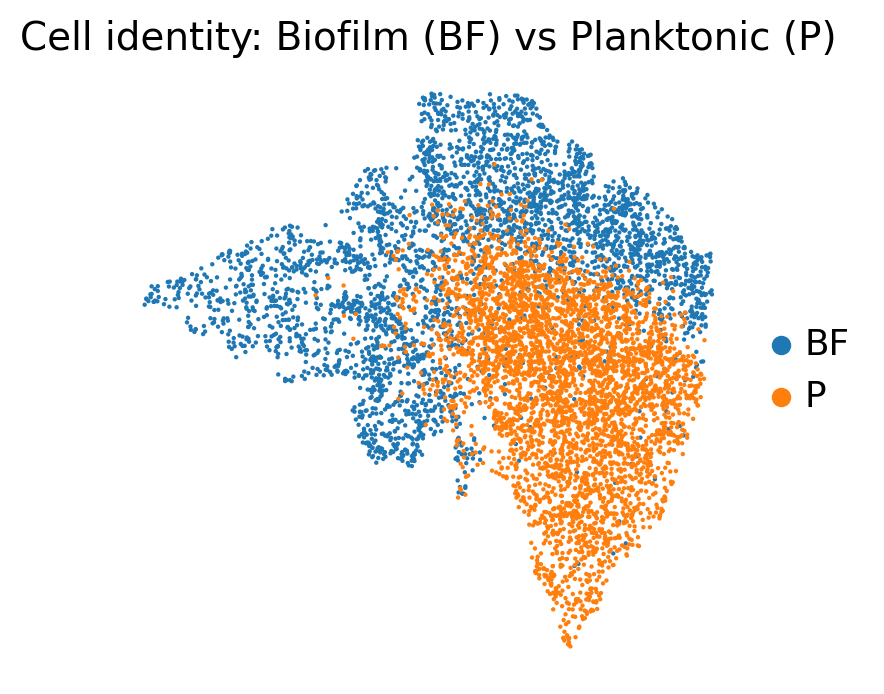

In [10]:
# Visualise Biofilm vs Planktonic on UMAP (Figure 2B in paper)
sc.pl.umap(
    adata_bacteria,
    color="Type_of_cells",
    size=10,
    title="Cell identity: Biofilm (BF) vs Planktonic (P)"
)

## 6. Leiden clustering (unsupervised)
The Leiden algorithm groups cells into clusters based on transcriptional similarity, without using any prior labels. Using a resolution of 0.15 — as specified in Korshoj & Kielian (2024) — the algorithm identifies 7 distinct subpopulations across the dataset. Each cluster potentially represents a unique transcriptional state within the Biofilm or Planktonic population.

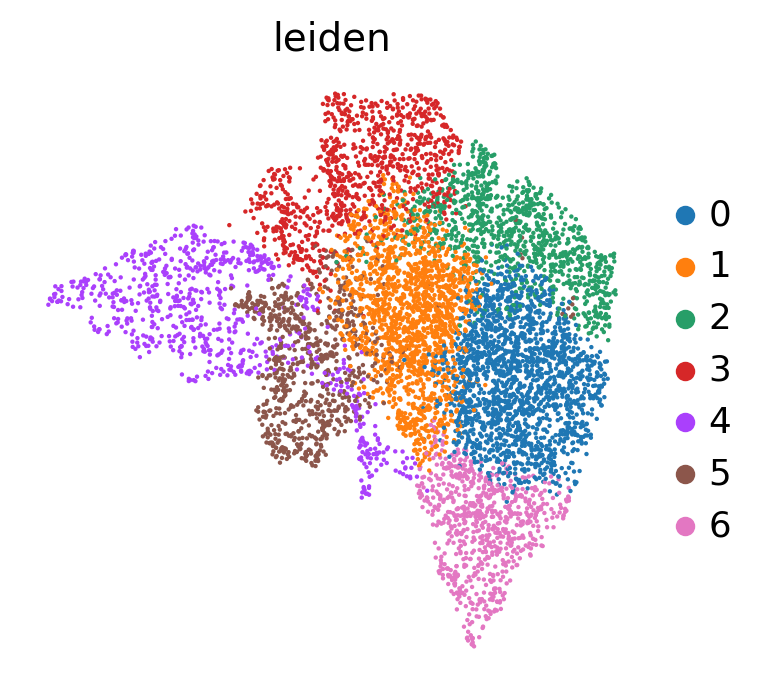

In [9]:
#sc.tl.leiden(adata_bacteria, flavor="igraph", n_iterations=2) #we dont use this anymore, because leidenalg is an older version, and dodnt now the "flavor" argument?
sc.tl.leiden(adata_bacteria, resolution= 0.15, n_iterations=2) #resolution of 0.15 and the algorithm repeats it 2 times for more stability
sc.pl.umap(adata_bacteria, color=["leiden"], size=10) #shows the UMAP coloured by cluster

In [11]:
# Check distribution of BF and P cells across each leiden cluster (like Figure 2D in paper)
import pandas as pd

distribution = pd.crosstab(
    adata_bacteria.obs['leiden'], 
    adata_bacteria.obs['Type_of_cells'],
    normalize='index'  # shows percentages per cluster
) * 100

print(distribution.round(1))

Type_of_cells    BF     P
leiden                   
0               7.3  92.7
1              16.7  83.3
2              92.9   7.1
3              97.0   3.0
4              86.7  13.3
5              88.8  11.2
6               1.1  98.9


## 7. Marker genes per cluster
To give biological meaning to the Leiden clusters, we identify the top marker genes per cluster using the Wilcoxon rank-sum test. This approach follows Korshoj & Kielian (2024), who used differential gene expression to characterise each transcriptional subpopulation. Genes that are highly expressed in one cluster compared to all others are considered marker genes for that cluster.